<a href="https://colab.research.google.com/github/madhu-80019/2420080019_ML/blob/main/ML_week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# PART A: SIMPLE PERCEPTRON
class Perceptron:
    def __init__(self):
        self.weights = None
        self.bias = 0

    def train(self, X, y, epochs=20):
        self.weights = np.zeros(X.shape[1])
        for _ in range(epochs):
            for i in range(len(X)):
                prediction = 1 if np.dot(X[i], self.weights) + self.bias >= 0 else 0
                error = y[i] - prediction
                self.weights += error * X[i]
                self.bias += error

    def predict(self, X):
        return np.array([1 if np.dot(x, self.weights) + self.bias >= 0 else 0 for x in X])


# PART B: 2-LAYER NEURAL NETWORK
class TwoLayerNN:
    def __init__(self):
        # Small random weights
        self.W1 = np.random.randn(2, 4) * 0.5
        self.b1 = np.zeros(4)
        self.W2 = np.random.randn(4, 1) * 0.5
        self.b2 = np.zeros(1)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def train(self, X, y, epochs=5000):
        y = y.reshape(-1, 1)
        for _ in range(epochs):
            # Forward pass
            hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
            output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)

            # Backward pass (simple gradient descent)
            output_error = output - y
            hidden_error = output_error.dot(self.W2.T) * hidden * (1 - hidden)

            # Update weights
            self.W2 -= 0.5 * hidden.T.dot(output_error)
            self.b2 -= 0.5 * np.sum(output_error, axis=0)
            self.W1 -= 0.5 * X.T.dot(hidden_error)
            self.b1 -= 0.5 * np.sum(hidden_error, axis=0)

    def predict(self, X):
        hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
        output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)
        return (output > 0.5).astype(int).flatten()

In [2]:
# PART C: SIMPLE KERAS-LIKE IMPLEMENTATION
class SimpleKeras:
    def __init__(self, hidden_neurons):
        self.W1 = np.random.randn(2, hidden_neurons) * 0.5
        self.b1 = np.zeros(hidden_neurons)
        self.W2 = np.random.randn(hidden_neurons, 1) * 0.5
        self.b2 = np.zeros(1)
        self.losses = []
        self.accuracies = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def fit(self, X, y, epochs=1000):
        y = y.reshape(-1, 1)
        for _ in range(epochs):
            # Forward
            hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
            output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)

            # Loss
            loss = np.mean((y - output) ** 2)
            self.losses.append(loss)

            # Accuracy
            acc = np.mean((output > 0.5) == y) * 100
            self.accuracies.append(acc)

            # Backward
            d_output = output - y
            d_hidden = d_output.dot(self.W2.T) * hidden * (1 - hidden)

            # Update
            self.W2 -= 0.5 * hidden.T.dot(d_output)
            self.b2 -= 0.5 * np.sum(d_output)
            self.W1 -= 0.5 * X.T.dot(d_hidden)
            self.b1 -= 0.5 * np.sum(d_hidden, axis=0)

    def predict(self, X):
        hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
        output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)
        return (output > 0.5).astype(int).flatten()


In [3]:
# ============MAIN PROGRAM ==================
print("=" * 60)
print("NEURAL NETWORKS FROM SCRATCH - XOR PROBLEM")
print("=" * 60)

# Create dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])
y_or = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

print("\n1. PERCEPTRON (Linear Classifier)")
print("-" * 40)

# Train on AND
p = Perceptron()
p.train(X, y_and, epochs=20)
print(f"AND: {p.predict(X)} (should be [0 0 0 1])")

# Train on OR
p.train(X, y_or, epochs=20)
print(f"OR:  {p.predict(X)} (should be [0 1 1 1])")

# Test on XOR
p.train(X, y_xor, epochs=50)
print(f"XOR: {p.predict(X)} (should be [0 1 1 0]) - PERCEPTRON FAILS!")

print("\n2. TWO-LAYER NEURAL NETWORK (Solves XOR)")
print("-" * 40)

nn = TwoLayerNN()
nn.train(X, y_xor)
print(f"XOR Result: {nn.predict(X)}")
print("✓ 2-Layer NN successfully learns XOR!")

print("\n3. COMPARING DIFFERENT ARCHITECTURES")
print("-" * 40)

# Try different hidden layer sizes
for neurons in [2, 4, 8]:
    model = SimpleKeras(hidden_neurons=neurons)
    model.fit(X, y_xor, epochs=1000)
    pred = model.predict(X)
    accuracy = np.mean(pred == y_xor) * 100
    print(f"Hidden neurons: {neurons:2d} → Accuracy: {accuracy:.0f}%")

NEURAL NETWORKS FROM SCRATCH - XOR PROBLEM

1. PERCEPTRON (Linear Classifier)
----------------------------------------
AND: [0 0 0 1] (should be [0 0 0 1])
OR:  [0 1 1 1] (should be [0 1 1 1])
XOR: [1 1 0 0] (should be [0 1 1 0]) - PERCEPTRON FAILS!

2. TWO-LAYER NEURAL NETWORK (Solves XOR)
----------------------------------------
XOR Result: [0 1 1 0]
✓ 2-Layer NN successfully learns XOR!

3. COMPARING DIFFERENT ARCHITECTURES
----------------------------------------
Hidden neurons:  2 → Accuracy: 100%
Hidden neurons:  4 → Accuracy: 100%
Hidden neurons:  8 → Accuracy: 100%


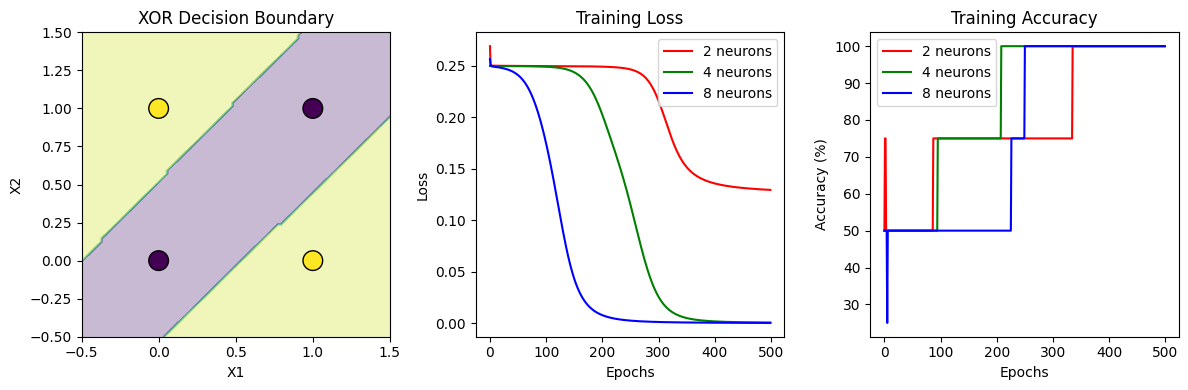


SUMMARY
✓ Perceptron: Works for AND/OR but fails for XOR (linear)
✓ 2-Layer NN: Successfully learns XOR (non-linear)
✓ More hidden neurons → Faster learning
✓ All implemented from scratch using only NumPy!


In [4]:
# Visualization
plt.figure(figsize=(12, 4))

# Plot 1: Decision boundary
plt.subplot(1, 3, 1)
model_viz = SimpleKeras(hidden_neurons=4)
model_viz.fit(X, y_xor, epochs=1000)

# Create grid
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model_viz.predict(grid).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y_xor, s=200, edgecolor='black')
plt.title('XOR Decision Boundary')
plt.xlabel('X1')
plt.ylabel('X2')

# Plot 2: Loss curves
plt.subplot(1, 3, 2)
for neurons, color in zip([2, 4, 8], ['red', 'green', 'blue']):
    m = SimpleKeras(neurons)
    m.fit(X, y_xor, epochs=500)
    plt.plot(m.losses, color=color, label=f'{neurons} neurons')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot 3: Accuracy curves
plt.subplot(1, 3, 3)
for neurons, color in zip([2, 4, 8], ['red', 'green', 'blue']):
    m = SimpleKeras(neurons)
    m.fit(X, y_xor, epochs=500)
    plt.plot(m.accuracies, color=color, label=f'{neurons} neurons')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print("✓ Perceptron: Works for AND/OR but fails for XOR (linear)")
print("✓ 2-Layer NN: Successfully learns XOR (non-linear)")
print("✓ More hidden neurons → Faster learning")
print("✓ All implemented from scratch using only NumPy!")